# PEMS11 数据预处理 — 生成 EAC 格式的 RawData / FastData / graph

将 `pems11/pems11_YYYY_flow.csv` 转换为 EAC 框架所需的三种数据，输出到 `preprocessed/pems11/`：

| 目录 | 内容 | 格式 |
|------|------|------|
| `preprocessed/pems11/RawData/` | 原始流量矩阵 | `{year}.npz`, key=`"x"`, shape `(T, N)` |
| `preprocessed/pems11/graph/` | 邻接矩阵 | `{year}_adj.npz`, key=`"x"`, shape `(N, N)` |
| `preprocessed/pems11/FastData/` | 预处理后的训练/验证/测试集 | `{year}.npz`, keys=`train_x/y, val_x/y, test_x/y, edge_index` |

处理逻辑与 EAC 原始 PEMS (District 7) 完全一致。

**工作目录**: 在 `xxltrafficdata/` 下运行本 notebook。

In [1]:
import os
import numpy as np
import pandas as pd
import tqdm
from math import radians, cos, sin, asin, sqrt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

# ======================== 配置 ========================
DISTRICT = "pems11"

# 输入数据 (相对于 xxltrafficdata/ 工作目录)
CSV_DIR = f"./{DISTRICT}"                              # flow CSV 所在目录
META_DIR = f"../meta/d11"                              # 传感器元数据目录
FLOW_PATTERN = f"{DISTRICT}_{{year}}_flow.csv"     # CSV 文件名模式
META_PREFIX = f"d11_text_meta_"                        # meta 文件前缀

# 输出数据 (相对于 xxltrafficdata/ 工作目录)
OUT_BASE = f"./preprocessed/{DISTRICT}"
RAW_DIR   = os.path.join(OUT_BASE, "RawData")
FAST_DIR  = os.path.join(OUT_BASE, "FastData")
GRAPH_DIR = os.path.join(OUT_BASE, "graph")

# EAC 超参数 (与 eac/conf/PEMS/eac.json 一致)
X_LEN = 12           # 输入窗口长度 (12 * 5min = 1h)
Y_LEN = 12           # 预测窗口长度
DAYS = 31            # 截取天数 (EAC 对 PEMS 数据取前 31 天)
TRAIN_RATE = 0.6
VAL_RATE = 0.2
TEST_RATE = 0.2
EPSILON = 0.1        # Gaussian kernel 邻接矩阵阈值

# 选择要处理的年份 (按需调整)
YEARS = [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(FAST_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)

print(f"District: {DISTRICT}")
print(f"Years to process: {YEARS}")
print(f"CSV_DIR:  {CSV_DIR}")
print(f"META_DIR: {META_DIR}")
print(f"Output:   {OUT_BASE}/ (RawData / FastData / graph)")

District: pems11
Years to process: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
CSV_DIR:  ./pems11
META_DIR: ../meta/d11
Output:   ./preprocessed/pems11/ (RawData / FastData / graph)


## Step 1: CSV -> RawData (原始流量矩阵)

读取每年的 CSV，去掉 Timestamp 列，保存为 `preprocessed/pemsXX/RawData/{year}.npz`，key=`"x"`，shape `(T, N)`。

In [2]:
raw_info = {}
for year in YEARS:
    csv_path = os.path.join(CSV_DIR, FLOW_PATTERN.format(year=year))
    out_path = os.path.join(RAW_DIR, f"{year}.npz")
    
    if not os.path.exists(csv_path):
        print(f"[SKIP] {csv_path} not found")
        continue
    
    # 读取 CSV: 第一列 Timestamp 作为 index，其余列是传感器
    df = pd.read_csv(csv_path, index_col=0)

    # NaN 清洗（每个 sensor 沿时间轴 ffill -> bfill -> 0 兜底）
    # 原因: 某些年份原始流量含大量缺失，下游 z_score 用 np.mean / np.std
    # 会把单个 NaN 扩散到整张 (train|val|test)_x，FastData 全坏、训练 loss 直接 NaN。
    nan_before = int(df.isna().values.sum())
    if nan_before > 0:
        df = df.ffill().bfill().fillna(0.0)
    nan_after = int(df.isna().values.sum())  # 兜底后应为 0

    data = df.values.astype(np.float32)  # (T, N)
    station_ids = [int(c) for c in df.columns]
    
    np.savez(out_path, x=data)
    
    nan_ratio = nan_before / data.size * 100 if data.size else 0.0
    raw_info[year] = {
        "T": data.shape[0],
        "N": data.shape[1],
        "days": data.shape[0] / 288,
        "station_ids": station_ids,
        "nan_filled": nan_before,
        "nan_ratio_pct": nan_ratio,
        "nan_remaining": nan_after,
        "file_size_MB": os.path.getsize(out_path) / 1024 / 1024
    }
    print(f"[{year}] shape=({data.shape[0]:>6d}, {data.shape[1]:>4d})  "
          f"days={data.shape[0]/288:>6.1f}  "
          f"NaN={nan_before:>9d} ({nan_ratio:>5.2f}%)  "
          f"size={raw_info[year]['file_size_MB']:.1f} MB  -> {out_path}")
    
    del df, data

print(f"\nTotal: {len(raw_info)} years processed")

[1999] shape=( 52992,  424)  days= 184.0  NaN=     5088 ( 0.02%)  size=85.7 MB  -> ./preprocessed/pems11\RawData\1999.npz
[2000] shape=(105408,  556)  days= 366.0  NaN=    14496 ( 0.02%)  size=223.6 MB  -> ./preprocessed/pems11\RawData\2000.npz
[2001] shape=(105120,  622)  days= 365.0  NaN=    58980 ( 0.09%)  size=249.4 MB  -> ./preprocessed/pems11\RawData\2001.npz
[2002] shape=(105120,  631)  days= 365.0  NaN=    15144 ( 0.02%)  size=253.0 MB  -> ./preprocessed/pems11\RawData\2002.npz
[2003] shape=(105120,  646)  days= 365.0  NaN=    15504 ( 0.02%)  size=259.0 MB  -> ./preprocessed/pems11\RawData\2003.npz
[2004] shape=(105408,  646)  days= 366.0  NaN=  1000104 ( 1.47%)  size=259.8 MB  -> ./preprocessed/pems11\RawData\2004.npz
[2005] shape=(105120,  838)  days= 365.0  NaN=    89232 ( 0.10%)  size=336.0 MB  -> ./preprocessed/pems11\RawData\2005.npz
[2006] shape=(105120,  944)  days= 365.0  NaN=   298272 ( 0.30%)  size=378.5 MB  -> ./preprocessed/pems11\RawData\2006.npz
[2007] shape=(105

## Step 2: 构建邻接矩阵 (graph)

与 EAC 一致，使用 Thresholded Gaussian Kernel：
- 基于传感器间 Haversine 地理距离
- $\sigma$ = 所有非零距离的标准差
- $\epsilon$ = 0.1（低于此值的边置零）
- 保存为 `preprocessed/pemsXX/graph/{year}_adj.npz`，key=`"x"`，shape `(N, N)`

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    """两点间的 Haversine 距离（公里）"""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * R * asin(sqrt(a))


def load_all_meta(meta_dir, prefix=META_PREFIX):
    """加载目录中所有 meta 文件路径，按文件名排序"""
    files = []
    for f in sorted(os.listdir(meta_dir)):
        if f.startswith(prefix) and f.endswith(".txt"):
            files.append(os.path.join(meta_dir, f))
    return files


def collect_station_coords(station_ids, meta_dir):
    """从多个 meta 文件中搜集每个 station 的经纬度"""
    needed = set(station_ids)
    coords = {}
    for mf in load_all_meta(meta_dir):
        if not needed:
            break
        meta = pd.read_csv(mf, sep="\t", usecols=["ID", "Latitude", "Longitude"])
        for _, row in meta.iterrows():
            sid = int(row["ID"])
            if sid in needed:
                lat, lon = row["Latitude"], row["Longitude"]
                if pd.notna(lat) and pd.notna(lon) and lat != 0 and lon != 0:
                    coords[sid] = (lat, lon)
                    needed.discard(sid)
    return coords, needed


def build_distance_matrix(station_ids, coords):
    """构建 N x N 距离矩阵 (km)"""
    N = len(station_ids)
    dist = np.zeros((N, N), dtype=np.float64)
    lats = [coords[sid][0] for sid in station_ids]
    lons = [coords[sid][1] for sid in station_ids]
    for i in range(N):
        for j in range(i + 1, N):
            d = haversine_km(lats[i], lons[i], lats[j], lons[j])
            dist[i, j] = d
            dist[j, i] = d
    return dist


def build_adj_gaussian(dist_matrix, epsilon=0.1):
    """Thresholded Gaussian Kernel 邻接矩阵"""
    nonzero_dists = dist_matrix[dist_matrix > 0]
    sigma = nonzero_dists.std()
    adj = np.exp(-dist_matrix ** 2 / sigma ** 2)
    adj[adj < epsilon] = 0.0
    np.fill_diagonal(adj, 0.0)
    return adj, sigma


print("Utility functions defined.")

Utility functions defined.


In [4]:
graph_info = {}

for year in YEARS:
    if year not in raw_info:
        continue
    
    station_ids = raw_info[year]["station_ids"]
    N = raw_info[year]["N"]
    out_path = os.path.join(GRAPH_DIR, f"{year}_adj.npz")
    
    # 收集经纬度
    coords, missing = collect_station_coords(station_ids, META_DIR)
    
    if missing:
        print(f"  [{year}] WARNING: {len(missing)} stations missing coords, using fallback")
        if coords:
            mean_lat = np.mean([c[0] for c in coords.values()])
            mean_lon = np.mean([c[1] for c in coords.values()])
            for sid in missing:
                coords[sid] = (mean_lat, mean_lon)
    
    # 构建距离矩阵和邻接矩阵
    dist_matrix = build_distance_matrix(station_ids, coords)
    adj, sigma = build_adj_gaussian(dist_matrix, epsilon=EPSILON)
    
    np.savez(out_path, x=adj.astype(np.float32))
    
    nonzero = np.count_nonzero(adj)
    avg_deg = (adj > 0).sum(axis=1).mean()
    
    graph_info[year] = {
        "N": N,
        "nonzero": nonzero,
        "sparsity": nonzero / (N * N) * 100,
        "avg_degree": avg_deg,
        "sigma_km": sigma,
        "missing_coords": len(missing) if missing else 0,
        "file_size_KB": os.path.getsize(out_path) / 1024
    }
    
    print(f"[{year}] N={N:>4d}  nonzero={nonzero:>8d} ({graph_info[year]['sparsity']:.2f}%)  "
          f"avg_deg={avg_deg:.1f}  sigma={sigma:.1f}km  -> {out_path}")

print(f"\nTotal: {len(graph_info)} adjacency matrices built")

[1999] N= 424  nonzero=   94164 (52.38%)  avg_deg=222.1  sigma=15.0km  -> ./preprocessed/pems11\graph\1999_adj.npz
[2000] N= 556  nonzero=  171516 (55.48%)  avg_deg=308.5  sigma=14.7km  -> ./preprocessed/pems11\graph\2000_adj.npz
[2001] N= 622  nonzero=  220518 (57.00%)  avg_deg=354.5  sigma=14.8km  -> ./preprocessed/pems11\graph\2001_adj.npz
[2002] N= 631  nonzero=  225180 (56.56%)  avg_deg=356.9  sigma=14.7km  -> ./preprocessed/pems11\graph\2002_adj.npz
[2003] N= 646  nonzero=  235702 (56.48%)  avg_deg=364.9  sigma=14.7km  -> ./preprocessed/pems11\graph\2003_adj.npz
[2004] N= 646  nonzero=  235702 (56.48%)  avg_deg=364.9  sigma=14.7km  -> ./preprocessed/pems11\graph\2004_adj.npz
  [2005] WARNING: 3 stations missing coords, using fallback
[2005] N= 838  nonzero=  393344 (56.01%)  avg_deg=469.4  sigma=14.8km  -> ./preprocessed/pems11\graph\2005_adj.npz
  [2006] WARNING: 1 stations missing coords, using fallback
[2006] N= 944  nonzero=  508388 (57.05%)  avg_deg=538.5  sigma=15.0km  -> .

## Step 3: 生成 FastData (预处理后的训练/验证/测试集)

与 `eac/utils/data_convert.py` 中 `generate_samples()` 逻辑完全一致：
1. 截取前 31 天数据 (`data[0 : 31*288, :]`)
2. 按 60/20/20 比例划分 train/val/test
3. 滑窗生成输入输出对 (x_len=12, y_len=12)
4. Z-score 归一化
5. 保存为 `preprocessed/pemsXX/FastData/{year}.npz`

In [5]:
def z_score(data):
    """Z-score 归一化 (NaN-robust: 与修复后的 eac/utils/data_convert.py 一致)

    使用 nanmean / nanstd，再将残余 NaN/Inf 置 0，避免单点缺失污染整张张量。
    在无 NaN 输入上与原 np.mean / np.std 数值等价（仅 +1e-8 的浮点小扰动）。
    """
    mean = np.nanmean(data)
    std = np.nanstd(data)
    out = (data - mean) / (std + 1e-8)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


def generate_dataset(data, idx, x_len=12, y_len=12):
    """滑窗生成输入输出对 (与 eac/utils/data_convert.py 一致)"""
    res = data[idx]
    node_size = data.shape[1]
    t = len(idx) - 1
    x_index, y_index = [], []
    
    for i in range(t, 0, -1):
        if i - x_len - y_len >= 0:
            x_index.extend(list(range(i - x_len - y_len, i - y_len)))
            y_index.extend(list(range(i - y_len, i)))
    
    x_index = np.asarray(x_index)
    y_index = np.asarray(y_index)
    x = res[x_index].reshape((-1, x_len, node_size))
    y = res[y_index].reshape((-1, y_len, node_size))
    return x, y


def generate_samples_eac(data, edge_index, days=31, x_len=12, y_len=12,
                         train_rate=0.6, val_rate=0.2):
    """生成 EAC 格式的 FastData (与 eac/utils/data_convert.py 逻辑一致)"""
    data = data[0 : days * 288, :]
    t, n = data.shape
    
    train_idx = list(range(int(t * train_rate)))
    val_idx   = list(range(int(t * train_rate), int(t * (train_rate + val_rate))))
    test_idx  = list(range(int(t * (train_rate + val_rate)), t))
    
    train_x, train_y = generate_dataset(data, train_idx, x_len, y_len)
    val_x, val_y     = generate_dataset(data, val_idx, x_len, y_len)
    test_x, test_y   = generate_dataset(data, test_idx, x_len, y_len)
    
    train_x = z_score(train_x)
    val_x   = z_score(val_x)
    test_x  = z_score(test_x)

    # y 保持原始量级（MSE 目标）。上游 RawData 已做过 NaN 清洗，这里再做一次
    # 防御性 nan_to_num，确保 FastData 中的 y 绝不会含 NaN/Inf。
    train_y = np.nan_to_num(train_y, nan=0.0, posinf=0.0, neginf=0.0)
    val_y   = np.nan_to_num(val_y,   nan=0.0, posinf=0.0, neginf=0.0)
    test_y  = np.nan_to_num(test_y,  nan=0.0, posinf=0.0, neginf=0.0)

    return {
        "train_x": train_x.astype(np.float32),
        "train_y": train_y.astype(np.float32),
        "val_x": val_x.astype(np.float32),
        "val_y": val_y.astype(np.float32),
        "test_x": test_x.astype(np.float32),
        "test_y": test_y.astype(np.float32),
        "edge_index": edge_index
    }

print("FastData generation functions defined.")

FastData generation functions defined.


In [6]:
fast_info = {}

for year in YEARS:
    if year not in raw_info:
        continue
    
    raw_path  = os.path.join(RAW_DIR, f"{year}.npz")
    adj_path  = os.path.join(GRAPH_DIR, f"{year}_adj.npz")
    out_path  = os.path.join(FAST_DIR, f"{year}.npz")
    
    data = np.load(raw_path)["x"]
    
    min_rows = DAYS * 288
    if data.shape[0] < min_rows:
        print(f"[{year}] WARNING: only {data.shape[0]} rows ({data.shape[0]/288:.1f} days), "
              f"need {min_rows} for {DAYS} days. Using all available data.")
        actual_days = int(data.shape[0] / 288)
    else:
        actual_days = DAYS
    
    adj = np.load(adj_path)["x"]
    graph = nx.from_numpy_array(adj)
    edge_index = np.array(list(graph.edges)).T
    
    result = generate_samples_eac(data, edge_index, days=actual_days, 
                                   x_len=X_LEN, y_len=Y_LEN,
                                   train_rate=TRAIN_RATE, val_rate=VAL_RATE)
    
    np.savez(out_path, **result)
    
    fast_info[year] = {
        "train_x": result["train_x"].shape,
        "val_x": result["val_x"].shape,
        "test_x": result["test_x"].shape,
        "edge_index": result["edge_index"].shape,
        "file_size_MB": os.path.getsize(out_path) / 1024 / 1024
    }
    
    print(f"[{year}] train={result['train_x'].shape}  val={result['val_x'].shape}  "
          f"test={result['test_x'].shape}  edges={result['edge_index'].shape}  "
          f"size={fast_info[year]['file_size_MB']:.1f} MB")
    
    del data, adj, graph, result

print(f"\nTotal: {len(fast_info)} FastData files generated")

[1999] train=(5332, 12, 424)  val=(1762, 12, 424)  test=(1762, 12, 424)  edges=(2, 47082)  size=344.1 MB
[2000] train=(5332, 12, 556)  val=(1762, 12, 556)  test=(1762, 12, 556)  edges=(2, 85758)  size=451.5 MB
[2001] train=(5332, 12, 622)  val=(1762, 12, 622)  test=(1762, 12, 622)  edges=(2, 110259)  size=505.2 MB
[2002] train=(5332, 12, 631)  val=(1762, 12, 631)  test=(1762, 12, 631)  edges=(2, 112590)  size=512.5 MB
[2003] train=(5332, 12, 646)  val=(1762, 12, 646)  test=(1762, 12, 646)  edges=(2, 117851)  size=524.7 MB
[2004] train=(5332, 12, 646)  val=(1762, 12, 646)  test=(1762, 12, 646)  edges=(2, 117851)  size=524.7 MB
[2005] train=(5332, 12, 838)  val=(1762, 12, 838)  test=(1762, 12, 838)  edges=(2, 196672)  size=680.9 MB
[2006] train=(5332, 12, 944)  val=(1762, 12, 944)  test=(1762, 12, 944)  edges=(2, 254194)  size=767.3 MB
[2007] train=(5332, 12, 1065)  val=(1762, 12, 1065)  test=(1762, 12, 1065)  edges=(2, 332831)  size=866.0 MB
[2008] train=(5332, 12, 1098)  val=(1762, 12,

## Step 4: 验证 & 总结

验证生成的文件格式与 EAC 原始数据一致，并汇总各年数据统计信息。

In [7]:
# 验证: 抽第一个已处理的年份，检查格式与 EAC 原始数据一致
sample_year = [y for y in YEARS if y in raw_info][0]
print(f"=== 验证 {sample_year} 年数据 ===\n")

raw = np.load(os.path.join(RAW_DIR, f"{sample_year}.npz"))
print(f"RawData keys: {list(raw.keys())}")
print(f"  x shape: {raw['x'].shape}, dtype: {raw['x'].dtype}\n")

adj = np.load(os.path.join(GRAPH_DIR, f"{sample_year}_adj.npz"))
print(f"graph keys: {list(adj.keys())}")
print(f"  x shape: {adj['x'].shape}, dtype: {adj['x'].dtype}")
print(f"  symmetric: {np.allclose(adj['x'], adj['x'].T)}")
print(f"  diagonal zero: {np.trace(adj['x']) == 0}\n")

fast = np.load(os.path.join(FAST_DIR, f"{sample_year}.npz"), allow_pickle=True)
print(f"FastData keys: {sorted(fast.keys())}")
for k in sorted(fast.keys()):
    print(f"  {k}: shape={fast[k].shape}, dtype={fast[k].dtype}")

print("\n=> 格式与 EAC 原始数据一致!")

=== 验证 1999 年数据 ===

RawData keys: ['x']
  x shape: (52992, 424), dtype: float32

graph keys: ['x']
  x shape: (424, 424), dtype: float32
  symmetric: True
  diagonal zero: True

FastData keys: ['edge_index', 'test_x', 'test_y', 'train_x', 'train_y', 'val_x', 'val_y']
  edge_index: shape=(2, 47082), dtype=int32
  test_x: shape=(1762, 12, 424), dtype=float32
  test_y: shape=(1762, 12, 424), dtype=float32
  train_x: shape=(5332, 12, 424), dtype=float32
  train_y: shape=(5332, 12, 424), dtype=float32
  val_x: shape=(1762, 12, 424), dtype=float32
  val_y: shape=(1762, 12, 424), dtype=float32

=> 格式与 EAC 原始数据一致!


In [8]:
# 汇总表
print(f"{'Year':>6s} | {'Sensors':>7s} | {'Raw days':>8s} | {'Raw MB':>7s} | "
      f"{'Adj nonzero%':>12s} | {'AvgDeg':>6s} | {'Fast MB':>7s} | "
      f"{'train':>16s} | {'val':>16s} | {'test':>16s}")
print("-" * 130)

for year in YEARS:
    if year not in raw_info:
        continue
    ri = raw_info[year]
    gi = graph_info[year]
    fi = fast_info[year]
    print(f"{year:>6d} | {ri['N']:>7d} | {ri['days']:>8.1f} | {ri['file_size_MB']:>7.1f} | "
          f"{gi['sparsity']:>11.2f}% | {gi['avg_degree']:>6.1f} | {fi['file_size_MB']:>7.1f} | "
          f"{str(fi['train_x']):>16s} | {str(fi['val_x']):>16s} | {str(fi['test_x']):>16s}")

  Year | Sensors | Raw days |  Raw MB | Adj nonzero% | AvgDeg | Fast MB |            train |              val |             test
----------------------------------------------------------------------------------------------------------------------------------
  1999 |     424 |    184.0 |    85.7 |       52.38% |  222.1 |   344.1 |  (5332, 12, 424) |  (1762, 12, 424) |  (1762, 12, 424)
  2000 |     556 |    366.0 |   223.6 |       55.48% |  308.5 |   451.5 |  (5332, 12, 556) |  (1762, 12, 556) |  (1762, 12, 556)
  2001 |     622 |    365.0 |   249.4 |       57.00% |  354.5 |   505.2 |  (5332, 12, 622) |  (1762, 12, 622) |  (1762, 12, 622)
  2002 |     631 |    365.0 |   253.0 |       56.56% |  356.9 |   512.5 |  (5332, 12, 631) |  (1762, 12, 631) |  (1762, 12, 631)
  2003 |     646 |    365.0 |   259.0 |       56.48% |  364.9 |   524.7 |  (5332, 12, 646) |  (1762, 12, 646) |  (1762, 12, 646)
  2004 |     646 |    366.0 |   259.8 |       56.48% |  364.9 |   524.7 |  (5332, 12, 646) |  (

## Step 5: 可视化 — 节点增长 & 邻接矩阵

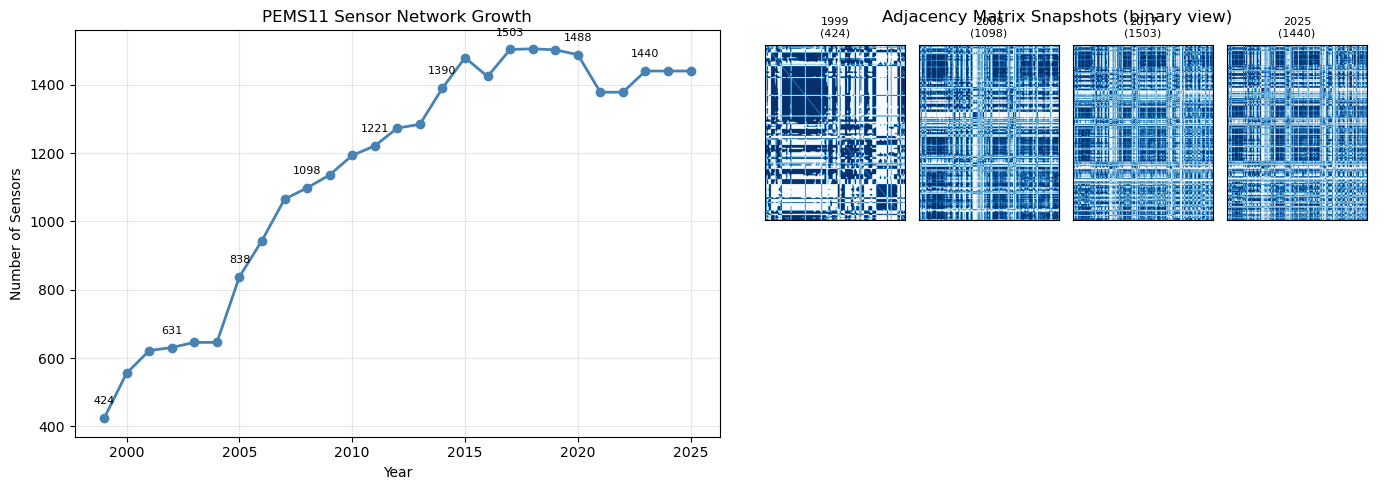

In [9]:
import matplotlib.pyplot as plt

years_list = [y for y in YEARS if y in raw_info]
nodes_list = [raw_info[y]["N"] for y in years_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(years_list, nodes_list, "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Sensors")
axes[0].set_title(f"{DISTRICT.upper()} Sensor Network Growth")
axes[0].grid(True, alpha=0.3)
for i, (x, y) in enumerate(zip(years_list, nodes_list)):
    if i % 3 == 0:
        axes[0].annotate(str(y), (x, y), textcoords="offset points", 
                        xytext=(0, 10), ha="center", fontsize=8)

sample_years = [y for y in [1999, 2008, 2017, 2025] if y in graph_info]
for i, sy in enumerate(sample_years):
    adj_data = np.load(os.path.join(GRAPH_DIR, f"{sy}_adj.npz"))["x"]
    ax_inset = fig.add_axes([0.55 + i * 0.11, 0.55, 0.10, 0.35])
    ax_inset.imshow(adj_data > 0, cmap="Blues", aspect="auto")
    ax_inset.set_title(f"{sy}\n({adj_data.shape[0]})", fontsize=8)
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])

axes[1].axis("off")
axes[1].set_title("Adjacency Matrix Snapshots (binary view)")

plt.tight_layout()
plt.show()

## Step 6: 生成 EAC 配置文件 (conf)

生成一个示例 EAC 配置 JSON，可直接用于 `python main.py --conf conf/PEMS11/eac.json`。

In [10]:
import json

eac_conf = {
    "begin_year": [y for y in YEARS if y in raw_info][0] if raw_info else YEARS[0],
    "end_year":   [y for y in YEARS if y in raw_info][-1] if raw_info else YEARS[-1],
    "dropout": 0.0,
    "lr": 0.03,
    "batch_size": 64,
    "epoch": 100,
    "gpuid": 0,
    "loss": "mse",
    "activation": "relu",
    "scheduler": "epo",
    "y_len": Y_LEN,
    "x_len": X_LEN,
    "data_process": 0,
    "raw_data_path": "data/PEMS11/RawData/",
    "save_data_path": "data/PEMS11/FastData/",
    "graph_path": "data/PEMS11/graph/",
    "model_path": "log/PEMS11/",
    "gcn": {
        "in_channel": 12,
        "out_channel": 12,
        "hidden_channel": 64
    },
    "tcn": {
        "in_channel": 1,
        "out_channel": 1,
        "kernel_size": 3,
        "dilation": 1
    },
    "method": "EAC",
    "logname": "eac",
    "rank": 6,
    "init": True,
    "train": 1,
    "auto_test": 1,
    "strategy": "retrain",
    "detect": False,
    "ewc": False,
    "replay": False
}

print("示例 EAC 配置 (conf/PEMS11/eac.json):")
print(json.dumps(eac_conf, indent=4))

print(f"\n使用方式: 将 preprocessed/{DISTRICT} 链接/复制到 eac/data/PEMS11/ 下:")
print(f"  ln -s $(pwd)/preprocessed/{DISTRICT}/RawData  ../eac/data/PEMS11/RawData")
print(f"  ln -s $(pwd)/preprocessed/{DISTRICT}/FastData ../eac/data/PEMS11/FastData")
print(f"  ln -s $(pwd)/preprocessed/{DISTRICT}/graph    ../eac/data/PEMS11/graph")

示例 EAC 配置 (conf/PEMS11/eac.json):
{
    "begin_year": 1999,
    "end_year": 2025,
    "dropout": 0.0,
    "lr": 0.03,
    "batch_size": 64,
    "epoch": 100,
    "gpuid": 0,
    "loss": "mse",
    "activation": "relu",
    "scheduler": "epo",
    "y_len": 12,
    "x_len": 12,
    "data_process": 0,
    "raw_data_path": "data/PEMS11/RawData/",
    "save_data_path": "data/PEMS11/FastData/",
    "graph_path": "data/PEMS11/graph/",
    "model_path": "log/PEMS11/",
    "gcn": {
        "in_channel": 12,
        "out_channel": 12,
        "hidden_channel": 64
    },
    "tcn": {
        "in_channel": 1,
        "out_channel": 1,
        "kernel_size": 3,
        "dilation": 1
    },
    "method": "EAC",
    "logname": "eac",
    "rank": 6,
    "init": true,
    "train": 1,
    "auto_test": 1,
    "strategy": "retrain",
    "detect": false,
    "ewc": false,
    "replay": false
}

使用方式: 将 preprocessed/pems11 链接/复制到 eac/data/PEMS11/ 下:
  ln -s $(pwd)/preprocessed/pems11/RawData  ../eac/data/PE

## Done!

输入 & 输出目录结构（工作目录 = `xxltrafficdata/`）：

**输入:**
```
xxltrafficdata/
├── pems11/
│   ├── pems11_{year}_flow.csv   # 原始 flow CSV
│   └── ...
└── (notebook 在 xxltrafficdata/ 下)

xxltrafficevo/meta/d11/            # 传感器元数据 (sibling 目录)
└── d11_text_meta_*.txt
```

**输出:**
```
xxltrafficdata/preprocessed/pems11/
├── RawData/
│   └── {year}.npz         # key="x", shape=(T, N)
├── FastData/
│   └── {year}.npz         # keys=[train_x/y, val_x/y, test_x/y, edge_index]
└── graph/
    └── {year}_adj.npz     # key="x", shape=(N, N)
```

可直接用于 EAC 框架训练。

In [ ]:
# ======================== Step 7: 验证 NaN / Inf / 异常值 ========================
# 逐年扫 RawData / FastData，确认:
#   (1) RawData 的 NaN / Inf 应为 0（Step 1 已做 ffill -> bfill -> 0 填充）
#   (2) FastData 6 个张量 (train/val/test_x/y) 都不应含 NaN / Inf
#   (3) 额外列出 RawData 的负值数 + 极端大值数，定位数据本身的异常
#   (4) z_score 后的 train_x 统计量应 mean≈0, std≈1（归一化健康度）

NEG_THRESHOLD = 0         # 流量 < 0 视为异常
EXTREME_FLOW = 2000       # 5min 单点流量 > 2000 在物理上极罕见

col_extreme = f"Raw>{EXTREME_FLOW}"
print(f"{'Year':>6s} | "
      f"{'RawNaN':>8s} {'RawInf':>7s} {'Raw<0':>9s} {col_extreme:>9s} | "
      f"{'FastNaN':>8s} {'FastInf':>8s} | "
      f"{'tx.mean':>9s} {'tx.std':>8s} {'ty.max':>9s}")
print("-" * 115)

bad_years = []
for year in YEARS:
    if year not in raw_info:
        continue
    raw_path  = os.path.join(RAW_DIR,  f"{year}.npz")
    fast_path = os.path.join(FAST_DIR, f"{year}.npz")
    if not (os.path.exists(raw_path) and os.path.exists(fast_path)):
        continue

    raw_x = np.load(raw_path)["x"]
    raw_nan = int(np.isnan(raw_x).sum())
    raw_inf = int(np.isinf(raw_x).sum())
    raw_neg = int((raw_x < NEG_THRESHOLD).sum())
    raw_big = int((raw_x > EXTREME_FLOW).sum())

    fast = np.load(fast_path)
    fast_nan_total = 0
    fast_inf_total = 0
    per_key_nan = {}
    for k in ("train_x", "train_y", "val_x", "val_y", "test_x", "test_y"):
        arr = fast[k]
        n = int(np.isnan(arr).sum())
        i = int(np.isinf(arr).sum())
        per_key_nan[k] = (n, i)
        fast_nan_total += n
        fast_inf_total += i

    tx = fast["train_x"]
    tx_mean = float(np.mean(tx))
    tx_std  = float(np.std(tx))
    ty_max  = float(np.max(fast["train_y"])) if fast["train_y"].size else 0.0

    flag = ""
    if raw_nan or raw_inf or fast_nan_total or fast_inf_total:
        flag = "  <-- BAD"
        bad_years.append((year, raw_nan, raw_inf, fast_nan_total, fast_inf_total, per_key_nan))

    print(f"{year:>6d} | "
          f"{raw_nan:>8d} {raw_inf:>7d} {raw_neg:>9d} {raw_big:>9d} | "
          f"{fast_nan_total:>8d} {fast_inf_total:>8d} | "
          f"{tx_mean:>+9.4f} {tx_std:>8.4f} {ty_max:>9.1f}{flag}")

print()
if not bad_years:
    print("[PASS] 所有年份 RawData / FastData 均无 NaN / Inf，源头修复生效。")
    print("       (Raw<0 / Raw>{} 若非 0 是数据本身的物理异常，不是 NaN 问题，看需求决定是否进一步清洗。)".format(EXTREME_FLOW))
else:
    print(f"[FAIL] {len(bad_years)} 个年份仍有 NaN / Inf:")
    for y, rn, ri, fn, fi, pk in bad_years:
        print(f"   {y}: RawNaN={rn}, RawInf={ri}, FastNaN={fn}, FastInf={fi}")
        for k, (n, i) in pk.items():
            if n or i:
                print(f"        {k}: nan={n}, inf={i}")

  Year |   RawNaN  RawInf     Raw<0  Raw>2000 |  FastNaN  FastInf |   tx.mean   tx.std    ty.max
-------------------------------------------------------------------------------------------------------------------
  1999 |        0       0         0         0 |        0        0 |   -0.0000   1.0000    1061.0
  2000 |        0       0         0         0 |        0        0 |   -0.0000   1.0000    1046.0
  2001 |        0       0         0         0 |        0        0 |   +0.0000   1.0000    1141.0
  2002 |        0       0         0         0 |        0        0 |   +0.0000   1.0000    1134.0
  2003 |        0       0         0         0 |        0        0 |   -0.0000   1.0000    1099.0
  2004 |        0       0         0         0 |        0        0 |   -0.0000   1.0000    1101.0
  2005 |        0       0         0         0 |        0        0 |   +0.0000   1.0000    1064.0
  2006 |        0       0         0         0 |        0        0 |   +0.0000   1.0000    1165.0
  2007 |   

: 